In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plasma = pd.read_csv('test4.csv')
background = pd.read_csv('back7.csv')


In [3]:
plasma.head()

,Wavelength_nm,Intensity
0,317.779,0.001732
1,318.882,0.001568
2,319.985,0.001978
3,321.088,0.002151
4,322.191,0.002487


In [4]:
background.head()

,Wavelength_nm,Intensity
0,317.779,0.000319
1,318.882,0.000409
2,319.985,0.000672
3,321.088,0.001171
4,322.191,0.001056


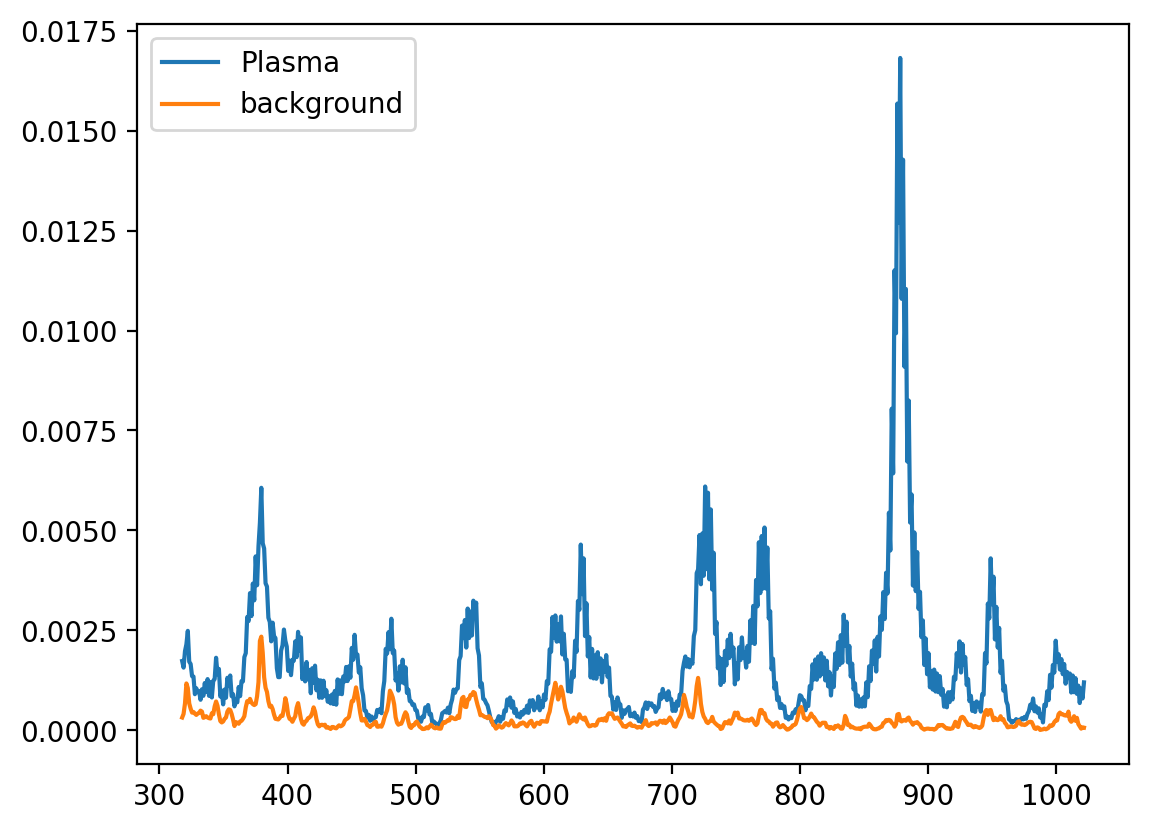

In [6]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], plasma['Intensity'], label='Plasma')
plt.plot(background['Wavelength_nm'], background['Intensity'], label='background')
plt.legend()

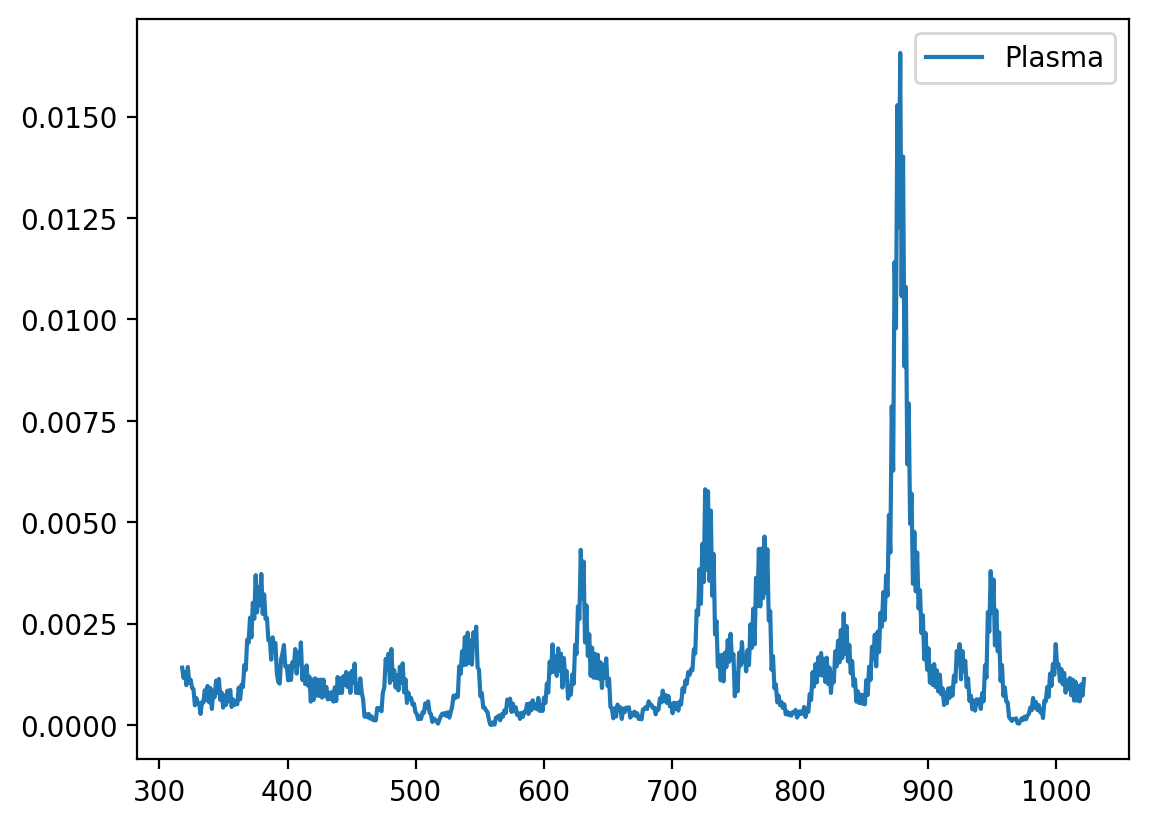

In [8]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], (plasma['Intensity']-background['Intensity']).clip(lower=0), label='Plasma')
plt.legend()

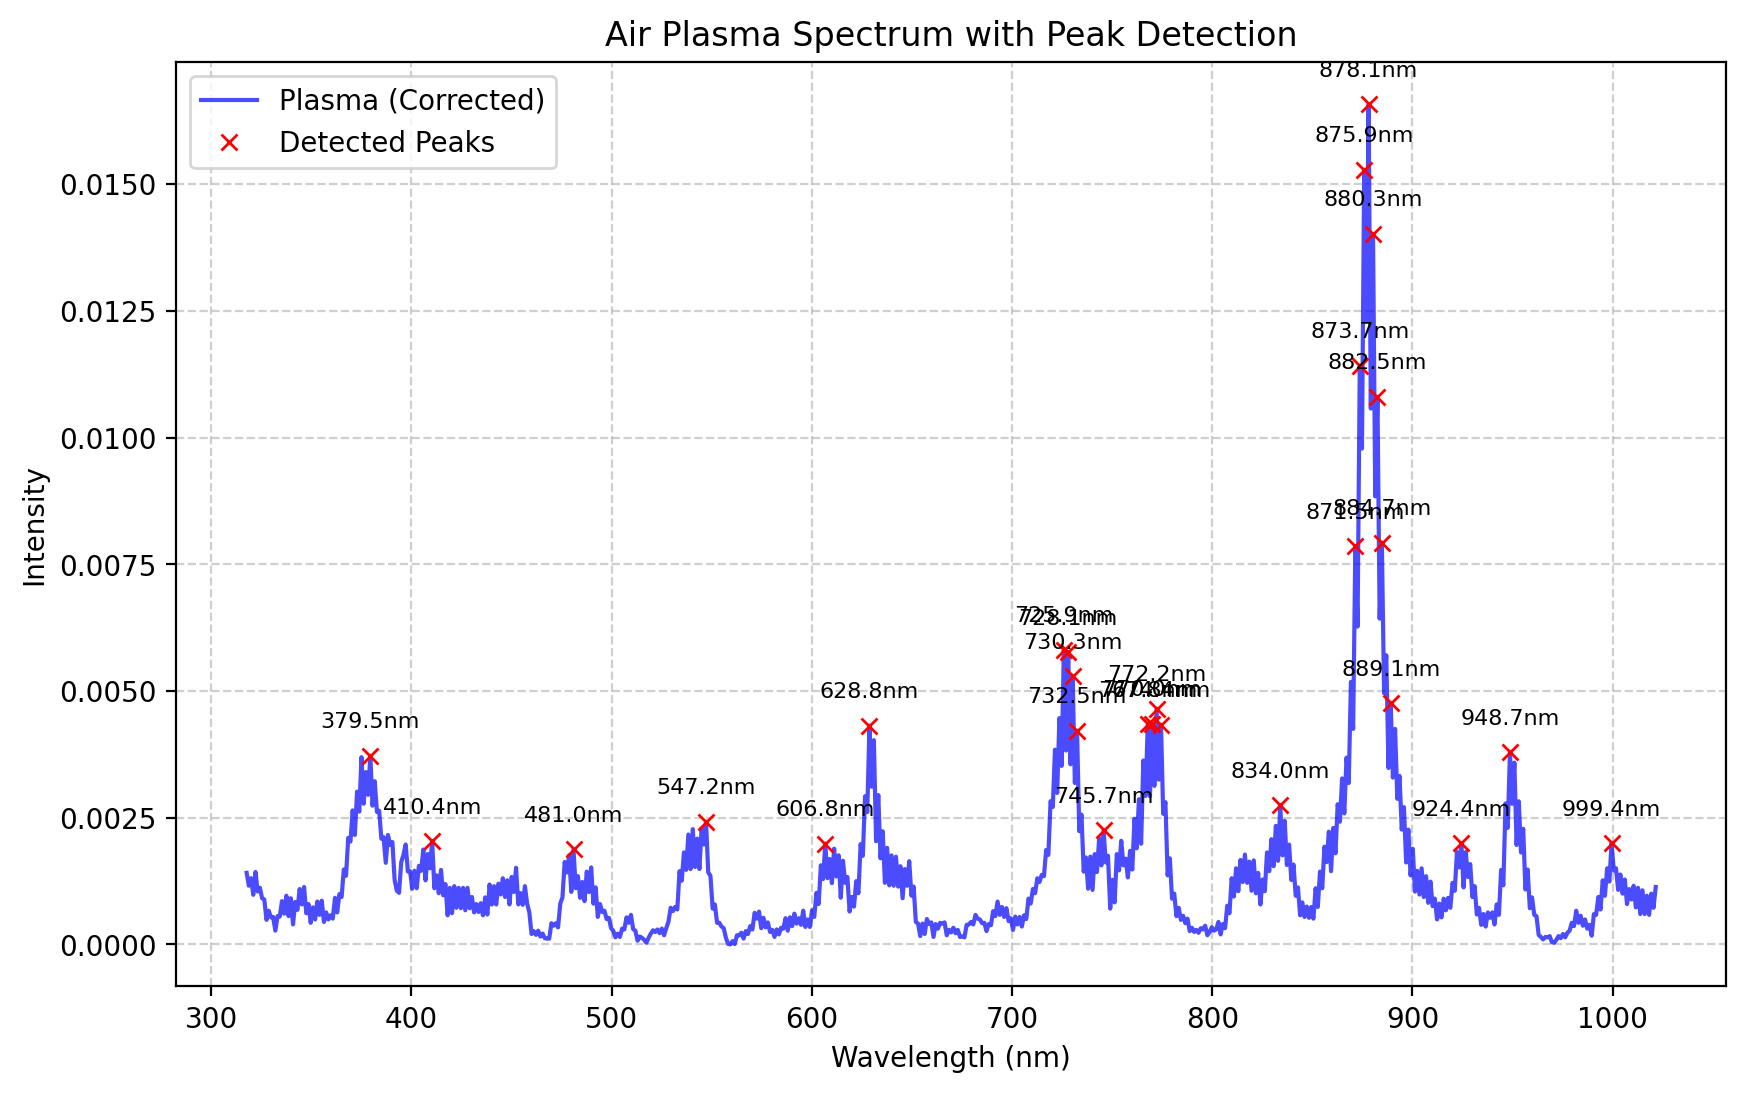

In [24]:
from scipy.signal import find_peaks

# 1. Calculate the corrected intensity
# We clip at 0 because negative intensity values (noise) don't represent a signal
corrected_intensity = (plasma['Intensity'] - background['Intensity']).clip(lower=0)
wavelengths = plasma['Wavelength_nm']

# 2. Find the peaks
# 'prominence' is key: it ignores small ripples/noise. 
# Adjust 'prominence' based on your signal-to-noise ratio.
peaks, properties = find_peaks(corrected_intensity, prominence = 0.001)

# 3. Plotting
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(wavelengths, corrected_intensity, label='Plasma (Corrected)', color='blue', alpha=0.7)

# Plot the identified peaks
plt.plot(wavelengths.iloc[peaks], corrected_intensity.iloc[peaks], "x", color='red', label='Detected Peaks')

# Optional: Annotate the peaks with their wavelength
for i in peaks:
    plt.annotate(f"{wavelengths.iloc[i]:.1f}nm", 
                 (wavelengths.iloc[i], corrected_intensity.iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Air Plasma Spectrum with Peak Detection')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()